In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
!ls /content/drive/MyDrive

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import os
from matplotlib import pyplot as plt
from PIL import Image

# =============================
# Dataset directory (Drive)
# =============================
DATA_DIR = "/content/drive/MyDrive/hamster_dataset/train/hamster"

# =============================
# Hyperparameters
# =============================
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 16  # fits GPU
NOISE_DIM = 100
EPOCHS = 200

# =============================
# Load dataset
# =============================
def load_dataset(data_dir):
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        directory=os.path.dirname(data_dir),
        labels=None,
        label_mode=None,
        image_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        shuffle=True
    )
    dataset = dataset.map(lambda x: (x - 127.5) / 127.5)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = load_dataset(DATA_DIR)

# =============================
# Generator (128x128 output)
# =============================
def make_generator_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(NOISE_DIM,)),

        layers.Dense(8 * 8 * 512, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((8, 8, 512)),  # 8x8

        layers.Conv2DTranspose(256, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),  # 16x16

        layers.Conv2DTranspose(128, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),  # 32x32

        layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),  # 64x64

        layers.Conv2DTranspose(3, 5, strides=2, padding='same',
                               use_bias=False, activation='tanh')  # 128x128
    ])
    return model

# =============================
# Discriminator (128x128 input)
# =============================
def make_discriminator_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(128, 128, 3)),

        layers.Conv2D(64, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(256, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

generator = make_generator_model()
discriminator = make_discriminator_model()

# =============================
# Loss & Optimizers
# =============================
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

gen_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)

# =============================
# Directory to save images
# =============================
save_dir = "/content/drive/MyDrive/hamster_generated_128"
os.makedirs(save_dir, exist_ok=True)

# =============================
# Generate and save images
# =============================
def generate_and_save_images(epoch):
    noise = tf.random.normal([16, NOISE_DIM])
    generated_images = generator(noise, training=False)

    plt.figure(figsize=(4, 4))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        img_array = (generated_images[i] * 127.5 + 127.5).numpy().astype("uint8")
        plt.imshow(img_array)
        plt.axis("off")
        # Save each image
        Image.fromarray(img_array).save(os.path.join(save_dir, f"epoch{epoch}_img{i+1}.png"))
    plt.show()

# =============================
# Training step
# =============================
@tf.function
def train_step(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_optimizer.apply_gradients(
        zip(gen_tape.gradient(gen_loss, generator.trainable_variables),
            generator.trainable_variables)
    )
    disc_optimizer.apply_gradients(
        zip(disc_tape.gradient(disc_loss, discriminator.trainable_variables),
            discriminator.trainable_variables)
    )

# =============================
# Training loop
# =============================
def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        for image_batch in dataset:
            train_step(image_batch)

        print(f"Epoch {epoch}/{epochs} completed")

        if epoch % 10 == 0:
            generate_and_save_images(epoch)

# =============================
# Start training
# =============================
train(train_dataset, EPOCHS)


In [ ]:
# Generate a batch of 16 images
import matplotlib.pyplot as plt
import numpy as np

noise = tf.random.normal([16, NOISE_DIM])
generated_images = generator(noise, training=False)

plt.figure(figsize=(4,4))
for i in range(16):
    plt.subplot(4, 4, i+1)
    img = (generated_images[i] * 127.5 + 127.5).numpy().astype("uint8")
    plt.imshow(img)
    plt.axis("off")
plt.show()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50 completed
Epoch 2/50 completed
Epoch 3/50 completed
Epoch 4/50 completed
Epoch 5/50 completed


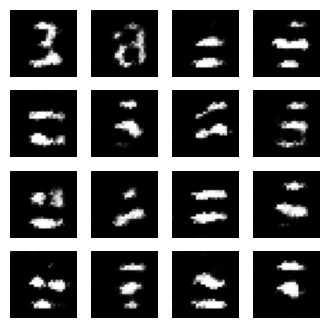

Epoch 6/50 completed
Epoch 7/50 completed
Epoch 8/50 completed
Epoch 9/50 completed
Epoch 10/50 completed


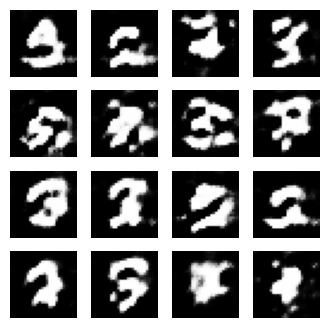

Epoch 11/50 completed


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import os

# =============================
# Hyperparameters
# =============================
IMG_HEIGHT = 28
IMG_WIDTH = 28
CHANNELS = 1
BATCH_SIZE = 256
NOISE_DIM = 100
EPOCHS = 100

# =============================
# Load MNIST dataset
# =============================
(train_images, _), (_, _) = tf.keras.datasets.mnist.load_data()
train_images = train_images.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize to [-1,1]

train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(60000).batch(BATCH_SIZE)

# =============================
# Generator
# =============================
def make_generator_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(NOISE_DIM,)),
        layers.Dense(7*7*256, use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7, 7, 256)),  # 7x7

        layers.Conv2DTranspose(128, 5, strides=1, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),  # 7x7

        layers.Conv2DTranspose(64, 5, strides=2, padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),  # 14x14

        layers.Conv2DTranspose(1, 5, strides=2, padding='same', use_bias=False, activation='tanh')  # 28x28x1
    ])
    return model

# =============================
# Discriminator
# =============================
def make_discriminator_model():
    model = tf.keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)),
        layers.Conv2D(64, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Conv2D(128, 5, strides=2, padding='same'),
        layers.LeakyReLU(),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1)
    ])
    return model

generator = make_generator_model()
discriminator = make_discriminator_model()

# =============================
# Loss & Optimizers
# =============================
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

gen_optimizer = tf.keras.optimizers.Adam(1e-4)
disc_optimizer = tf.keras.optimizers.Adam(1e-4)

# =============================
# Directory to save images
# =============================
save_dir = "./mnist_generated"
os.makedirs(save_dir, exist_ok=True)

# =============================
# Generate and save images
# =============================
def generate_and_save_images(epoch):
    noise = tf.random.normal([16, NOISE_DIM])
    generated_images = generator(noise, training=False)

    plt.figure(figsize=(4, 4))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        img_array = (generated_images[i, :, :, 0] * 127.5 + 127.5).numpy().astype("uint8")
        plt.imshow(img_array, cmap='gray')
        plt.axis("off")
        Image.fromarray(img_array).save(os.path.join(save_dir, f"epoch{epoch}_img{i+1}.png"))
    plt.show()

# =============================
# Training step
# =============================
@tf.function
def train_step(images):
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_optimizer.apply_gradients(
        zip(gen_tape.gradient(gen_loss, generator.trainable_variables),
            generator.trainable_variables)
    )
    disc_optimizer.apply_gradients(
        zip(disc_tape.gradient(disc_loss, discriminator.trainable_variables),
            discriminator.trainable_variables)
    )

# =============================
# Training loop
# =============================
def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        for image_batch in dataset:
            train_step(image_batch)

        print(f"Epoch {epoch}/{epochs} completed")

        if epoch % 5 == 0:
            generate_and_save_images(epoch)

# =============================
# Start training
# =============================
train(train_dataset, EPOCHS)
